In [1]:
# Imports
import json
from pathlib import Path

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
HUGE_COURT_GEOJSON = "C:\\Users\\Zachary\\phd_classes\\geog572\\final\\data\\external\\huge_basketball_court.geojson"
PLAYERS_DOWNSAMPLED = "C:\\Users\\Zachary\\phd_classes\\geog572\\final\\data\\processed\\player_positions_downsampled_25_frames.csv"

# Read the downsampleed data as
df_downsampled = pd.read_csv(PLAYERS_DOWNSAMPLED)


# Read huge court and get bounds
huge_court = gpd.read_file(HUGE_COURT_GEOJSON)
xmin, ymin, xmax, ymax = huge_court.total_bounds

print("Huge court bounds:")
print(f"xmin={xmin}, xmax={xmax}, ymin={ymin}, ymax={ymax}")

# Standard NBA tracking extent
NBA_XMIN, NBA_XMAX = 0.0, 94.0
NBA_YMIN, NBA_YMAX = 0.0, 50.0

# Copy your downsampled dataframe
df_huge = df_downsampled.copy()

# ---- orientation controls ----
# Start with these. If it looks wrong, toggle them.
SWAP_AXES = True   # False = keep (x,y), True = use (y,x)
FLIP_X = False
FLIP_Y = False

# Choose source coordinates
if SWAP_AXES:
    src_x = df_huge["y"].astype(float).copy()
    src_y = df_huge["x"].astype(float).copy()
    src_xmin, src_xmax = NBA_YMIN, NBA_YMAX   # 0..50
    src_ymin, src_ymax = NBA_XMIN, NBA_XMAX   # 0..94
else:
    src_x = df_huge["x"].astype(float).copy()
    src_y = df_huge["y"].astype(float).copy()
    src_xmin, src_xmax = NBA_XMIN, NBA_XMAX   # 0..94
    src_ymin, src_ymax = NBA_YMIN, NBA_YMAX   # 0..50

# Optional flips
if FLIP_X:
    src_x = src_xmax - (src_x - src_xmin)

if FLIP_Y:
    src_y = src_ymax - (src_y - src_ymin)

# Min-max scale source court coords into huge court bounds
df_huge["x_huge"] = xmin + ((src_x - src_xmin) / (src_xmax - src_xmin)) * (xmax - xmin)
df_huge["y_huge"] = ymin + ((src_y - src_ymin) / (src_ymax - src_ymin)) * (ymax - ymin)

df_huge[["player_name", "frame_idx", "x", "y", "x_huge", "y_huge"]].head()

Huge court bounds:
xmin=-115.37234042553192, xmax=-94.62765957446808, ymin=17.5, ymax=56.5


,player_name,frame_idx,x,y,x_huge,y_huge
0,Kyle Korver,0,45.70423,15.57870,-108.908837,36.462393
1,Paul Millsap,0,56.87016,22.95879,-105.846885,41.095066
2,Al Horford,0,47.26914,24.47616,-105.217338,37.111664
3,Jeff Teague,0,28.26728,23.73400,-105.525255,29.227914
4,Kent Bazemore,0,40.59368,31.74141,-102.203032,34.342059


In [6]:
df_huge.head()

,event_id,frame_idx,period,wall_time_ms,game_clock,shot_clock,team_id,team_abbr,team_name,player_id,player_name,jersey,position,x,y,z,x_huge,y_huge
0,1,0,1,1445991110020,720.0,24.0,1610612737,ATL,Atlanta Hawks,2594,Kyle Korver,26,G,45.70423,15.57870,0.0,-108.908837,36.462393
1,1,0,1,1445991110020,720.0,24.0,1610612737,ATL,Atlanta Hawks,200794,Paul Millsap,4,F,56.87016,22.95879,0.0,-105.846885,41.095066
2,1,0,1,1445991110020,720.0,24.0,1610612737,ATL,Atlanta Hawks,201143,Al Horford,15,F-C,47.26914,24.47616,0.0,-105.217338,37.111664
3,1,0,1,1445991110020,720.0,24.0,1610612737,ATL,Atlanta Hawks,201952,Jeff Teague,0,G,28.26728,23.73400,0.0,-105.525255,29.227914
4,1,0,1,1445991110020,720.0,24.0,1610612737,ATL,Atlanta Hawks,203145,Kent Bazemore,24,G,40.59368,31.74141,0.0,-102.203032,34.342059


In [8]:
df_huge.to_csv("C:\\Users\\Zachary\\phd_classes\\geog572\\final\\data\\processed\\player_positions_downsampled_25_frames_huge.csv")

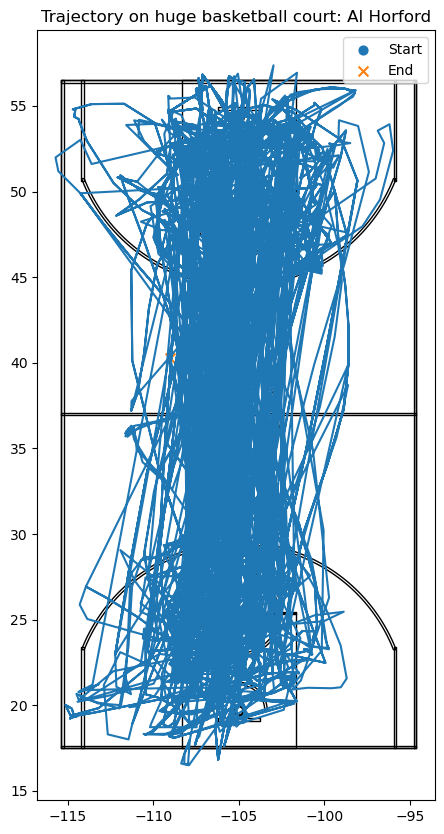

In [ ]:
sample_player = "Al Horford"

g = df_huge[df_huge["player_name"] == sample_player].sort_values("frame_idx")

fig, ax = plt.subplots(figsize=(10, 10))
huge_court.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)

ax.plot(g["x_huge"], g["y_huge"], linewidth=1.5)
ax.scatter(g["x_huge"].iloc[0], g["y_huge"].iloc[0], s=40, marker="o", label="Start")
ax.scatter(g["x_huge"].iloc[-1], g["y_huge"].iloc[-1], s=50, marker="x", label="End")

ax.set_title(f"Trajectory on huge basketball court: {sample_player}")
ax.set_aspect("equal")
ax.legend()
plt.show()